In [1]:
# Import settings/
nb_settings_path = "./settings.py"
with open(nb_settings_path) as f:
    code = f.read()
    exec(code)

In [2]:
import os
import re
import math
import itertools
from typing import List
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib.ticker import FormatStrFormatter

import seaborn as sns

import statsmodels.api as sm

from utils import FORMAT_N, FORMAT_D, N_color_map, D_color_map, N_ticks, D_ticks
from utils_scaling_fit import plot_diagnostic, plot_diagnostic_1d, plot_diagnostic_2d, bootstrap_test_null
from utils_plotting import plot_hp_vs_ND_fix_other, plot_hp_vs_DN

def fit(df, y, x):
    y = df[y]
    X = sm.add_constant(df[x])
    return sm.OLS(y, X).fit()


In [3]:
SEQ_LEN = 4096

# full dataset
df_all = pd.read_csv('../data/loss_all_exps_post_annealing.csv')

# best HP
df_best_lr = pd.read_csv('../data/best_HPs/lr_min.csv')
df_best_gbsz = pd.read_csv('../data/best_HPs/gbsz_min.csv')
df_best_lr_gbsz = pd.read_csv('../data/best_HPs/lr_gbsz_min.csv')

# HP from quadratic fit
df_best_lr_smooth = pd.read_csv('../data/best_HPs/lr_min_smooth.csv')
df_best_lr_sliced = pd.read_csv('../data/best_HPs/lr_min_sliced.csv')
df_best_gbsz_sliced = pd.read_csv('../data/best_HPs/gbsz_min_sliced.csv')

# Load quadratic fits
fit_2d_lr_gbsz = pd.read_parquet('../data/quadratic_fits/fit_2d_lr_gbsz.parquet')
fit_2d_sliced_lr = pd.read_parquet('../data/quadratic_fits/fit_2d_sliced_lr.parquet')
fit_2d_sliced_gbsz = pd.read_parquet('../data/quadratic_fits/fit_2d_sliced_gbsz.parquet')


# Fit

In [4]:
# Data
df = df_best_lr_sliced.copy()
df_fit = df[df.N != 1_713_504_256].reset_index(drop=True)

del df

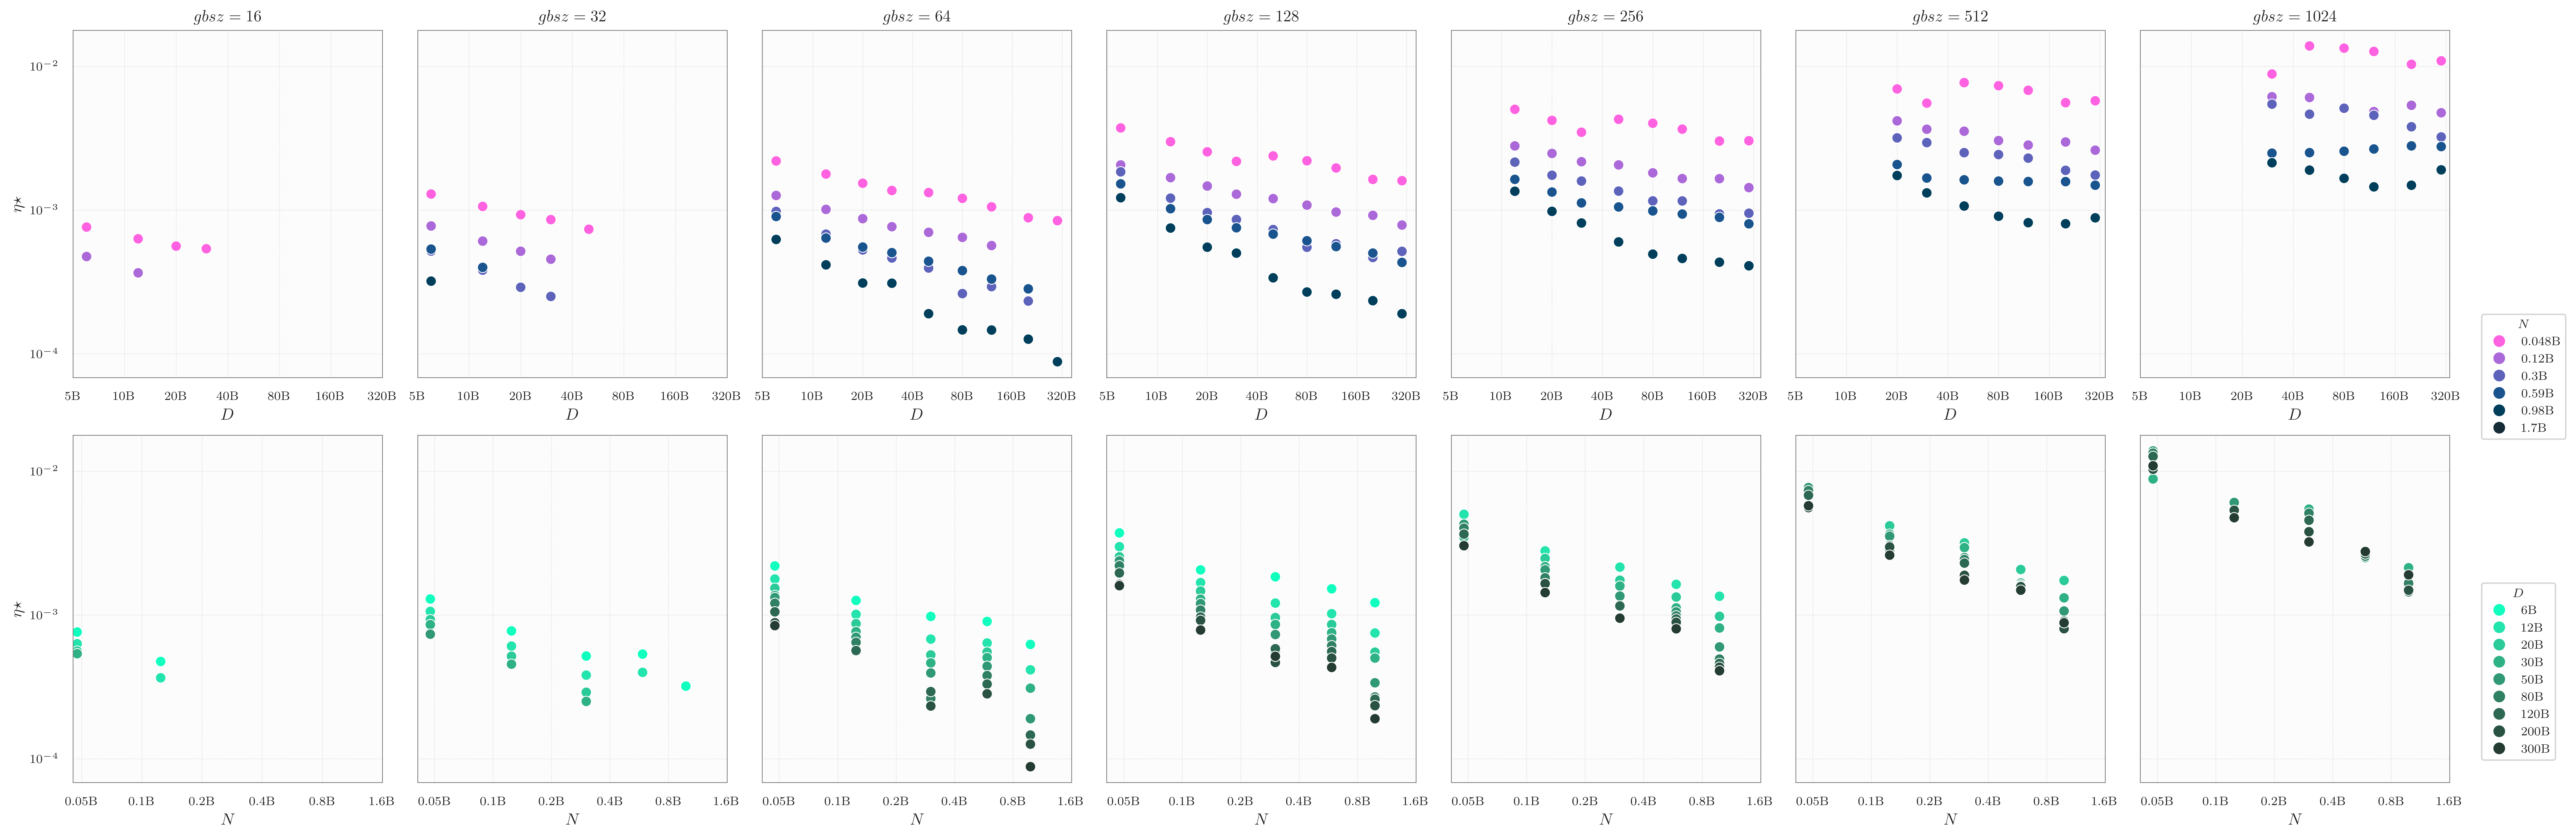

In [5]:
## Data Visualization
plot_hp_vs_ND_fix_other(
    df_fit,
    y='lr',
    other_fixed='gbsz',
)

In [6]:
# --- data prep / outlier removal ---

# Data
df = df_fit.copy()

# Drop batch sizes where we have too few points
df = df[df.gbsz != 16].reset_index(drop=True)

# # Uncertain estimates from the quadratic fit
df = df[~(
    (df.gbsz == 128) &
    (df.D >= 200e9)
)].reset_index(drop=True)
df = df[~(
    (df.gbsz == 64) &
    (df.D >= 120e9)
)].reset_index(drop=True)

# How many data points?
print(f"n = {df.shape[0]} data points")

n = 186 data points


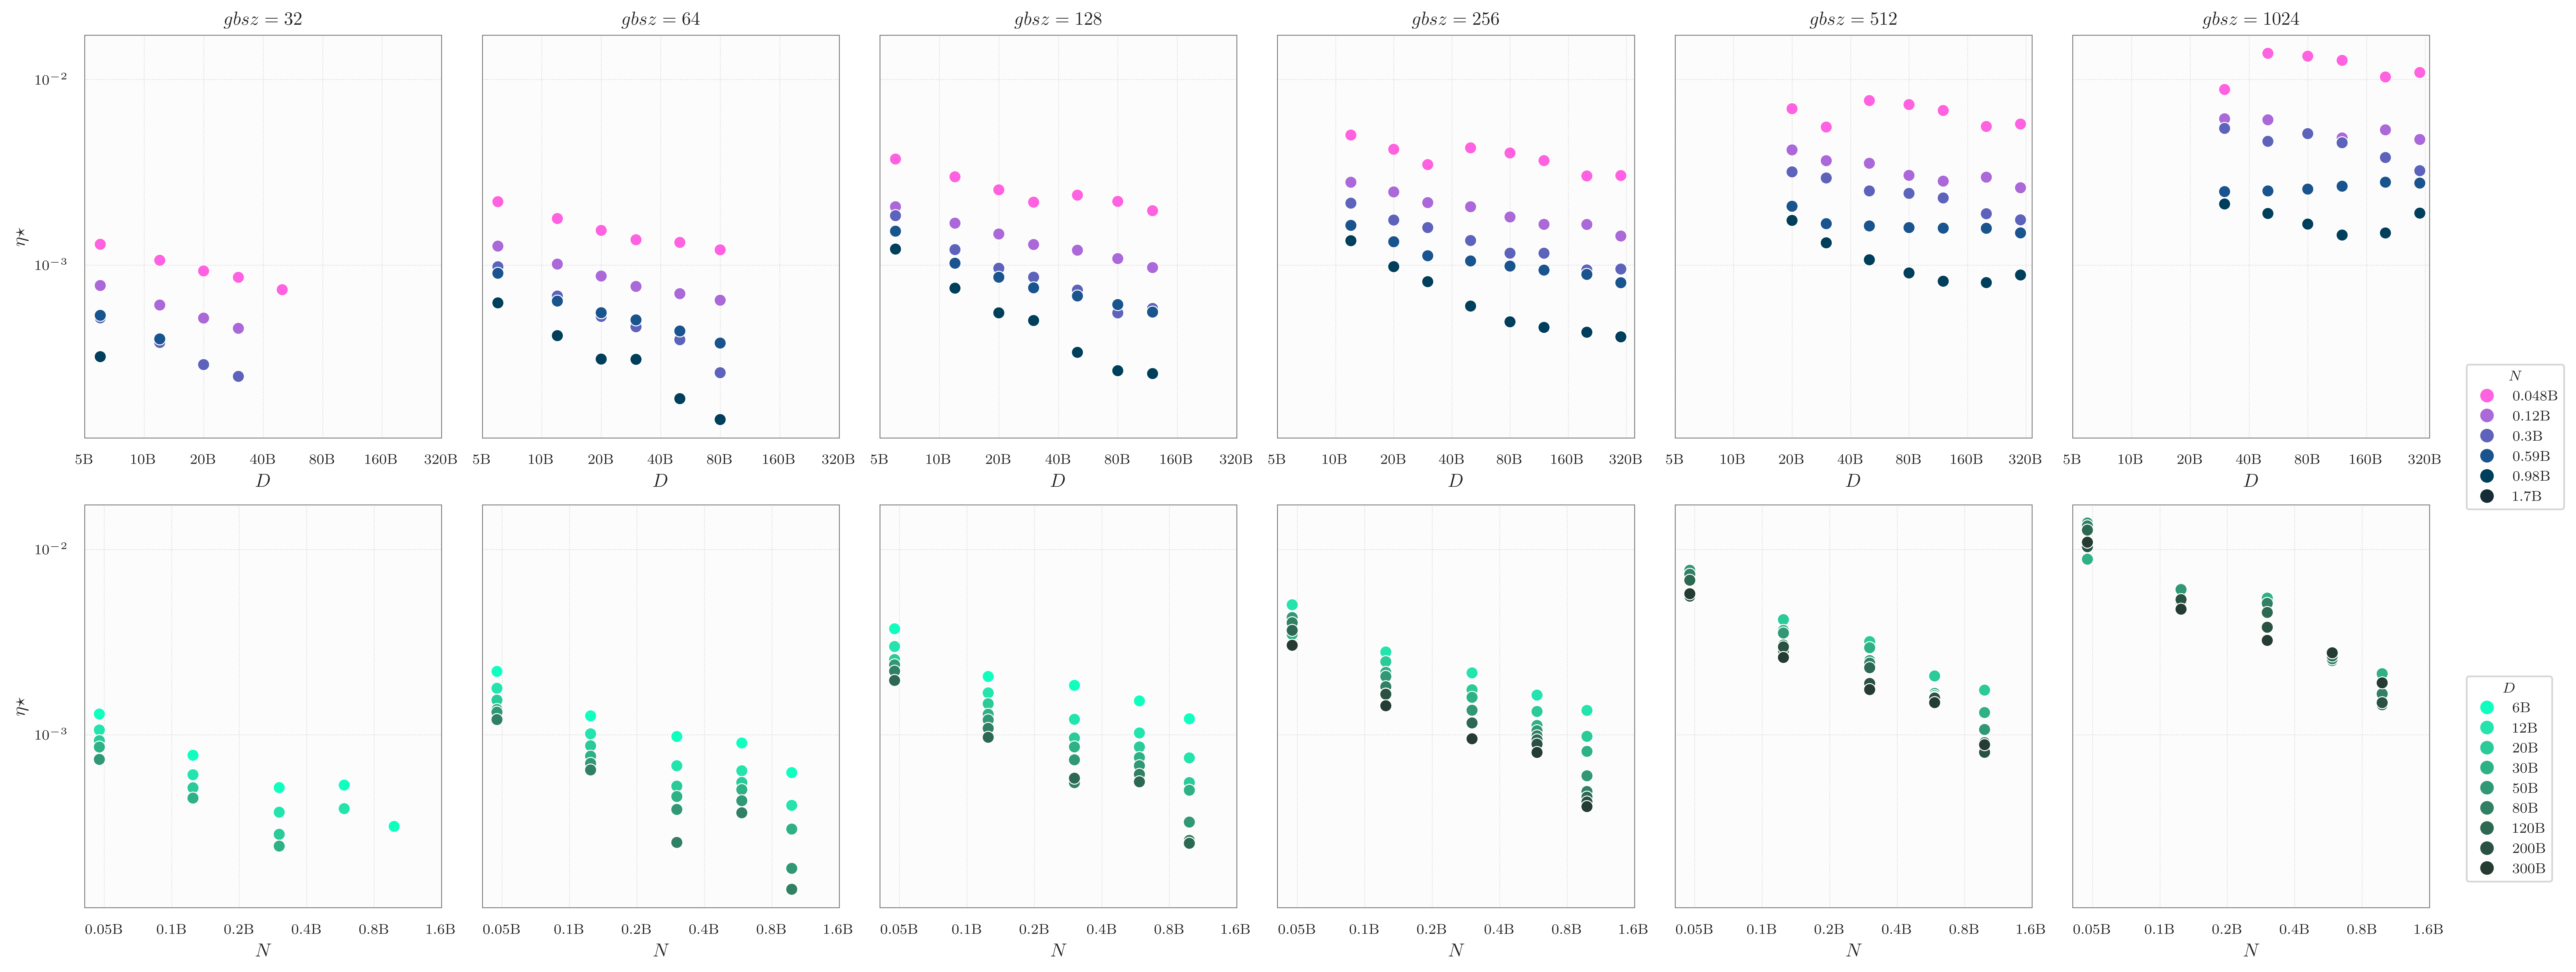

In [7]:
## Data Visualization
plot_hp_vs_ND_fix_other(
    df,
    y='lr',
    other_fixed='gbsz',
)

                            OLS Regression Results                            
Dep. Variable:                      l   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     938.4
Date:                Fri, 28 Aug 2026   Prob (F-statistic):          6.97e-137
Time:                        10:37:08   Log-Likelihood:                 89.875
No. Observations:                 186   AIC:                            -163.7
Df Residuals:                     178   BIC:                            -137.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.5983      0.013   -499.694      0.0

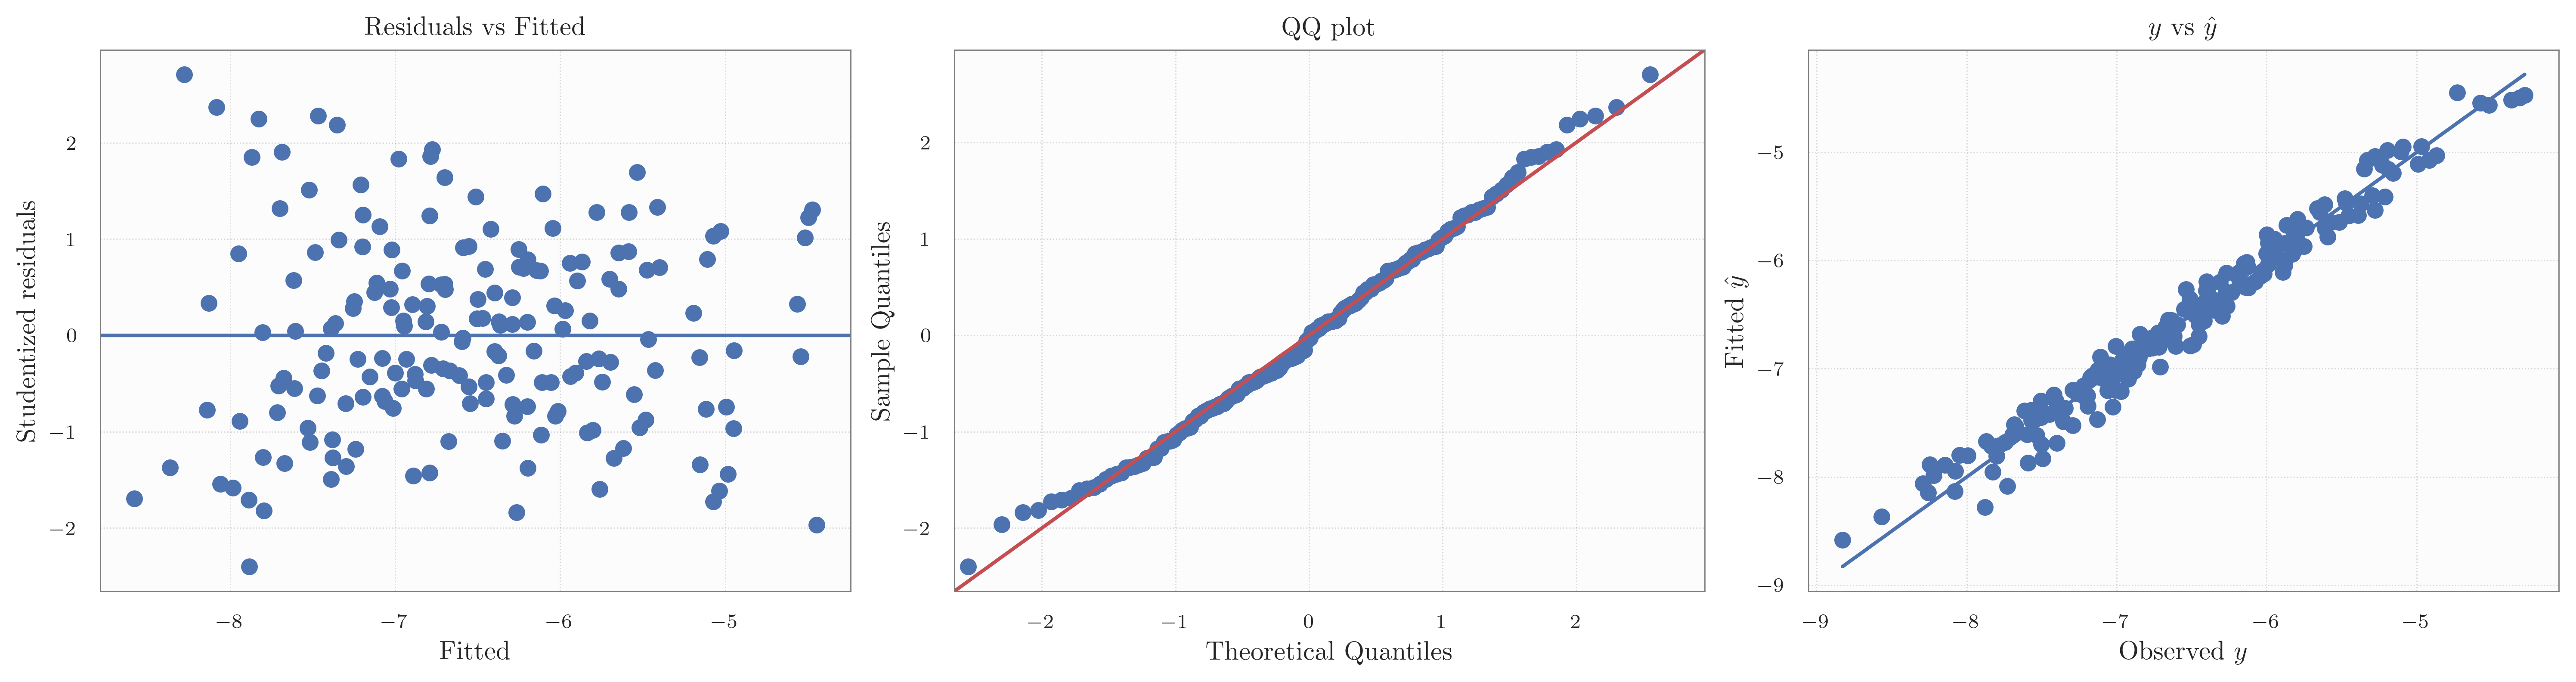

In [8]:
# --- Fit full model ---

df['l'] = np.log(df['lr'])
df['d'] = np.log(df['D'])
df['n'] = np.log(df['N'])
df['b'] = np.log(df['gbsz'])

# center
for v in ['d','n','b']:
    df[v] -= df[v].mean()

# interactions
df['dn']  = df['d'] * df['n']
df['db']  = df['d'] * df['b']
df['nb']  = df['n'] * df['b']
df['dnb'] = df['d'] * df['n'] * df['b']

m_full   = fit(df, y='l', x=['d','n','b','dn','db','nb','dnb'])
print(m_full.summary())
plot_diagnostic(m_full)


In [9]:
# --- Build latex table from fit ---

rows = []

for name in m_full.params.index:

    coef = m_full.params[name]
    pval = m_full.pvalues[name]

    rows.append({
        "term": name,
        "coef": coef,
        "pvalue": pval,
    })

df_latex = pd.DataFrame(rows)

term_map = {
    "const": r"$\mathrm{const}$",
    "d": r"$\log D$",
    "n": r"$\log N$",
    "b": r"$\log b$",
    "dn": r"$\log D \log N$",
    "db": r"$\log D \log b$",
    "nb": r"$\log N \log b$",
    "dnb": r"$\log D \log N \log b$",
}

df_latex["term"] = df_latex["term"].map(term_map)

def latex_fmt(x):
    if abs(x) < 1e-8:
        return r"$\approx 0$"
    return rf"${x:.7f}$"

latex_table = df_latex.to_latex(
    index=False,
    escape=False,
    column_format="lcc",
    caption=rf"Fitted coefficients and p-values for \autoref{{eq:lr_vs_bND_full_model}} (n={int(m_full.nobs)}, dof={int(m_full.df_resid)}, $R^2={m_full.rsquared.item():.3f}$).",
    label="tab:lr_vs_bND_full_model",
    formatters={
        "coef": latex_fmt,
        "pvalue": latex_fmt,
    },
)

print(latex_table)

\begin{table}
\caption{Fitted coefficients and p-values for \autoref{eq:lr_vs_bND_full_model} (n=186, dof=178, $R^2=0.974$).}
\label{tab:lr_vs_bND_full_model}
\begin{tabular}{lcc}
\toprule
term & coef & pvalue \\
\midrule
$\mathrm{const}$ & $-6.5982501$ & $\approx 0$ \\
$\log D$ & $-0.2450907$ & $\approx 0$ \\
$\log N$ & $-0.5410536$ & $\approx 0$ \\
$\log b$ & $0.7998060$ & $\approx 0$ \\
$\log D \log N$ & $-0.0635849$ & $0.0000000$ \\
$\log D \log b$ & $0.0831131$ & $\approx 0$ \\
$\log N \log b$ & $0.0012659$ & $0.9133354$ \\
$\log D \log N \log b$ & $0.0154444$ & $0.1171394$ \\
\bottomrule
\end{tabular}
\end{table}



In [10]:
## Can we drop two interaction terms?
print(bootstrap_test_null(df, # H0: reduced model is true
    'l',
    ['d','n','b','dn','db','nb','dnb'],
    ['d','n','b','dn','db'])[1])

## Yes, pvalue is high for the JOINT bootstrap test

0.278


                            OLS Regression Results                            
Dep. Variable:                      l   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     1310.
Date:                Fri, 28 Aug 2026   Prob (F-statistic):          1.82e-139
Time:                        10:37:12   Log-Likelihood:                 88.588
No. Observations:                 186   AIC:                            -165.2
Df Residuals:                     180   BIC:                            -145.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.5985      0.013   -499.809      0.0

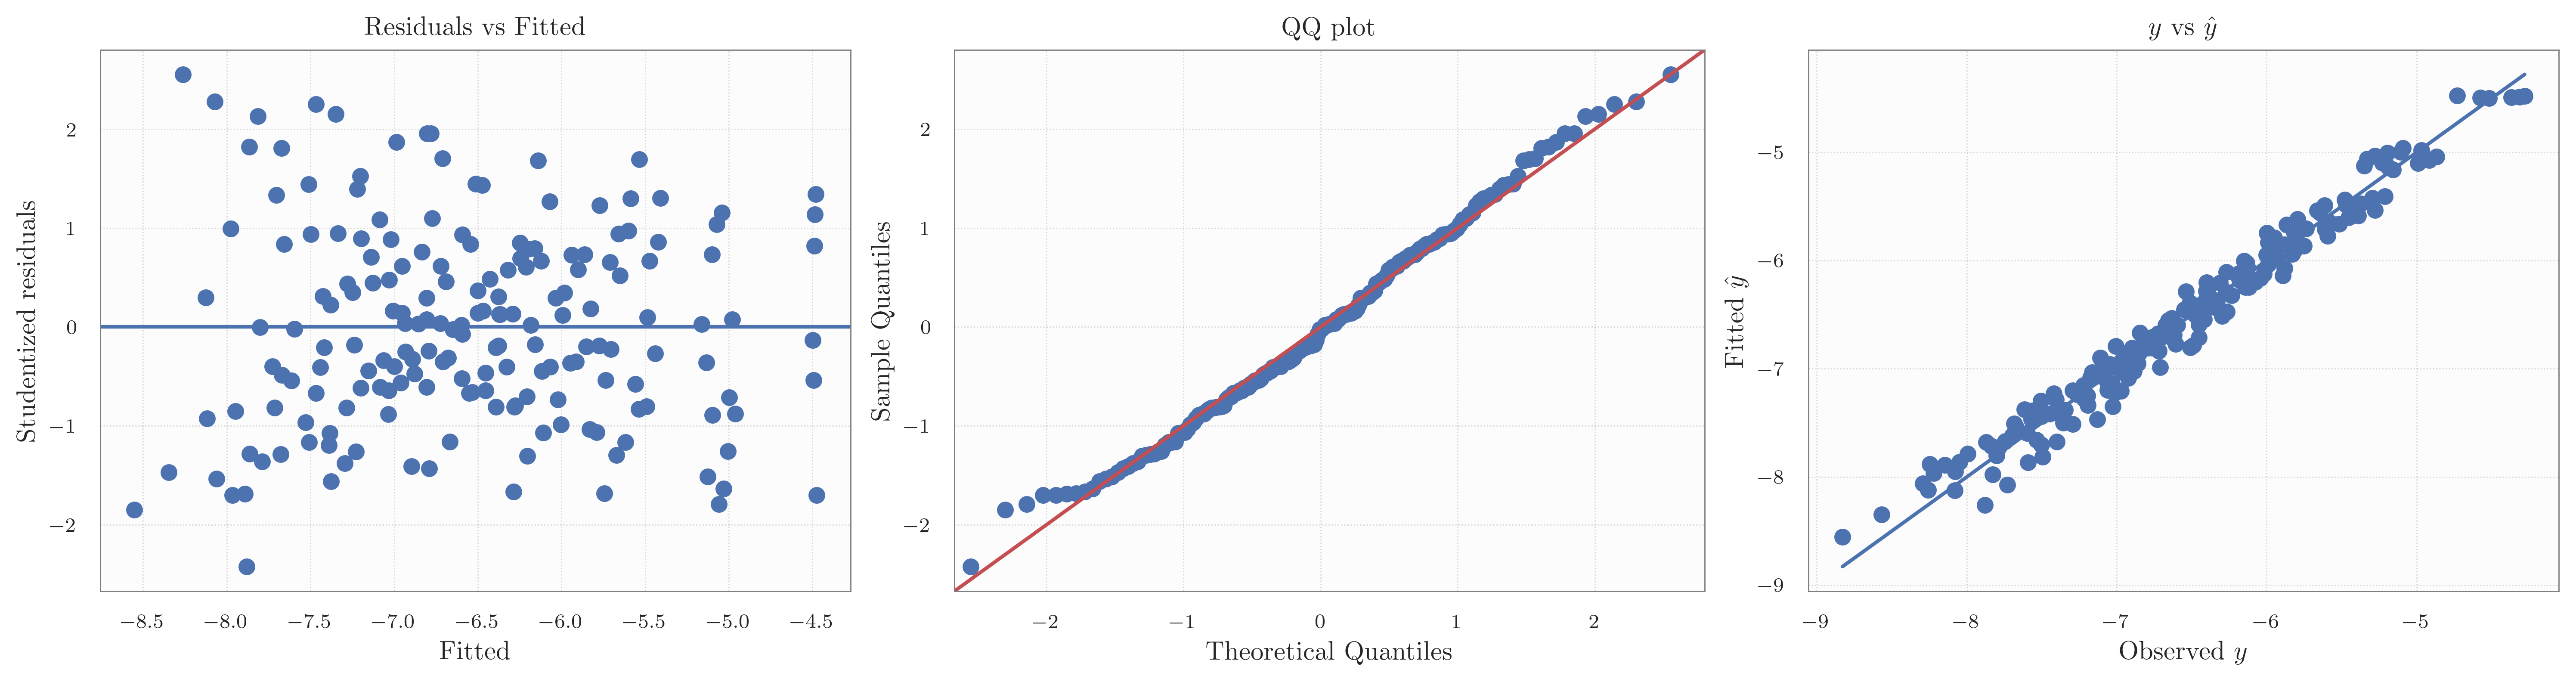

In [11]:
# --- Fit reduced model ---

df['l'] = np.log(df['lr'])
df['d'] = np.log(df['D'])
df['n'] = np.log(df['N'])
df['b'] = np.log(df['gbsz'])

# center
for v in ['d','n','b']:
    df[v] -= df[v].mean()

# interactions
df['dn'] = df['d'] * df['n']
df['db'] = df['d'] * df['b']

m_reduced = fit(df, y='l', x=['d','n','b','dn','db'])
print(m_reduced.summary())
plot_diagnostic(m_reduced)


In [12]:
p = m_reduced.params

print(rf"""
\begin{{equation}}
\log \eta^\star = {p['const']:+.2f} {p['b']:+.2f} \log b {p['n']:+.2f} \log N {p['d']:+.2f} \log D {p['dn']:+.2f} \log N \log D {p['db']:+.2f} \log D \log b.
\label{{eq:scaling_lr_arbitrary_bsz_fit_reduced}}
\end{{equation}}
""")


\begin{equation}
\log \eta^\star = -6.60 +0.80 \log b -0.53 \log N -0.24 \log D -0.06 \log N \log D +0.08 \log D \log b.
\label{eq:scaling_lr_arbitrary_bsz_fit_reduced}
\end{equation}



### Plot

In [13]:
# --- General Settings ---

# df is the train set
df_plot = df.copy()

# Means used for centering
d0 = np.log(df['D']).mean()
n0 = np.log(df['N']).mean()
b0 = np.log(df['gbsz']).mean()

# Column values
bszs = [128, 256, 512, 1024]
n_bszs = len(bszs)

# Axes grid
D_grid = np.geomspace(df['D'].min(), df['D'].max(), 200)
N_grid = np.geomspace(df['N'].min(), df['N'].max(), 200)

# Confidence intervals setting
CONF_LEVEL = 0.95
CONF_LABEL = f"{100*CONF_LEVEL:.0f}\\% CI"

# Plotting setting
fit_line_kwargs = {
    "linewidth": 1,
    "alpha": 0.9,
}
ci_kwargs = {
    "alpha": 0.1,
    "linewidth": 0.25,
}

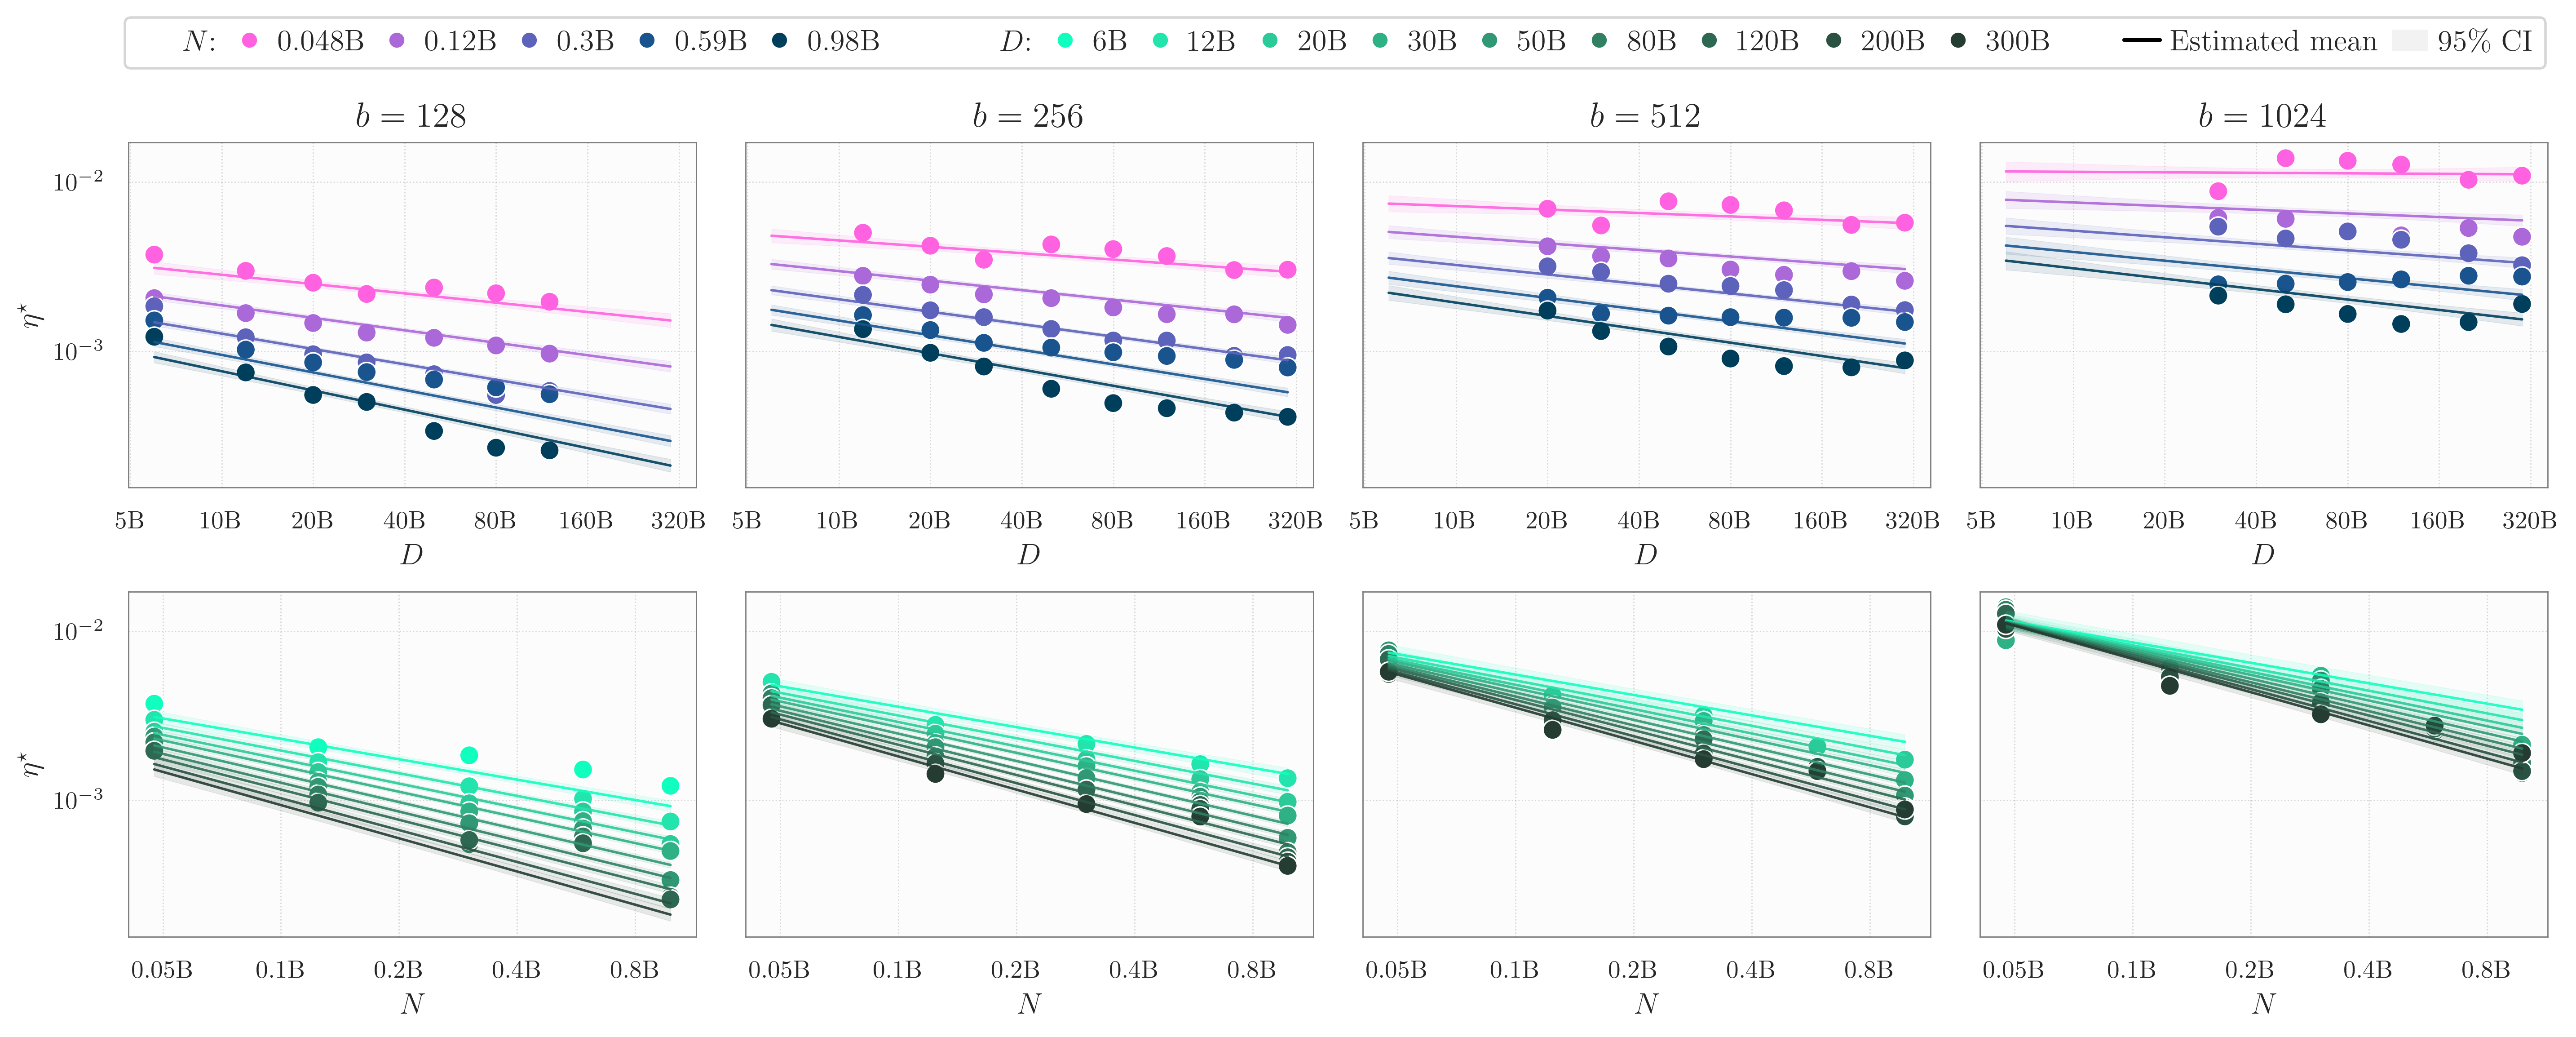

In [14]:
# -------------------------------------------------
# PLOT REDUCED MODEL FITS
# -------------------------------------------------

model = m_reduced


fig, axes = plt.subplots(
    2,
    n_bszs,
    figsize=(3.6 * n_bszs, 5.5),
    squeeze=False,
    sharey="all",
)


for c, bsz in enumerate(bszs):

    df_b = df_plot[df_plot['gbsz'] == bsz]

    # =================================================
    # ROW 0: lr vs D
    # =================================================

    sns.scatterplot(
        data=df_b,
        x="D",
        y="lr",
        hue="N",
        palette=N_color_map,
        s=60,
        ax=axes[0, c]
    )

    for N, color in list(N_color_map.items())[:-1]: # skip 1.7B
        assert N <= 1e9, "1.7B should be reserved for validation!"

        X = pd.DataFrame({
            "d": np.log(D_grid) - d0,
            "n": np.log(N) - n0,
            "b": np.log(bsz) - b0,
        })
        X['dn'] = X['d'] * X['n']
        X['db'] = X['d'] * X['b']
        X = sm.add_constant(X, has_constant="add")
        sf = model.get_prediction(X).summary_frame(alpha=1-CONF_LEVEL)
        
        mean = np.exp(sf["mean"])
        lo   = np.exp(sf["mean_ci_lower"])
        hi   = np.exp(sf["mean_ci_upper"])

        axes[0, c].plot(D_grid, mean, color=color, **fit_line_kwargs)
        axes[0, c].fill_between(D_grid, lo, hi, color=color, **ci_kwargs)

    axes[0, c].set_xscale("log")
    axes[0, c].set_yscale("log")
    axes[0, c].set_title(rf"$b={bsz}$", fontsize=14)
    axes[0, c].set_xlabel(r"$D$", fontsize=12)
    axes[0, c].set_ylabel(r"$\eta^\star$", fontsize=12)
    axes[0, c].set_xticks(D_ticks)
    axes[0, c].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: FORMAT_D(x)))
    axes[0, c].tick_params(axis="both", labelsize=10)
    axes[0, c].legend_.remove()

    # =================================================
    # ROW 1: lr vs N
    # =================================================

    sns.scatterplot(
        data=df_b,
        x="N",
        y="lr",
        hue="D",
        palette=D_color_map,
        s=60,
        ax=axes[1, c]
    )

    for D, color in D_color_map.items():

        X = pd.DataFrame({
            "d": np.log(D) - d0,
            "n": np.log(N_grid) - n0,
            "b": np.log(bsz) - b0,
        })
        X['dn'] = X['d'] * X['n']
        X['db'] = X['d'] * X['b']
        X = sm.add_constant(X, has_constant="add")
        sf = model.get_prediction(X).summary_frame(alpha=1-CONF_LEVEL)

        mean = np.exp(sf["mean"])
        lo   = np.exp(sf["mean_ci_lower"])
        hi   = np.exp(sf["mean_ci_upper"])

        axes[1, c].plot(N_grid, mean, color=color, **fit_line_kwargs)
        axes[1, c].fill_between(N_grid, lo, hi, color=color, **ci_kwargs)

    axes[1, c].set_xscale("log")
    axes[1, c].set_yscale("log")
    axes[1, c].set_xlabel(r"$N$", fontsize=12)
    axes[1, c].set_ylabel(r"$\eta^\star$", fontsize=12)
    axes[1, c].set_xticks(N_ticks[:-1])
    axes[1, c].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: FORMAT_N(x)))
    axes[1, c].tick_params(axis="both", labelsize=10)
    axes[1, c].legend_.remove()

# =================================================
# Legend
# =================================================
    
handles = []

# N header
handles.append(Line2D([], [], linestyle="None", label=r"$N$:"))
handles += [
    Line2D([], [], marker="o", linestyle="None", markerfacecolor=c, markeredgecolor="none", markersize=6, label=FORMAT_N(N))
    for N, c in list(N_color_map.items())[:-1]
    
]
# spacer
handles.append(Line2D([], [], linestyle="None", label="   ")) 

# D header
handles.append(Line2D([], [], linestyle="None", label=r"$D$:"))
handles += [
    Line2D([], [], marker="o", linestyle="None", markerfacecolor=c, markeredgecolor="none", markersize=6, label=FORMAT_D(D))
    for D, c in D_color_map.items()
]
# spacer
handles.append(Line2D([], [], linestyle="None", label="   "))

# style entries
handles += [
    Line2D([0], [0], color="black", lw=1.5, label="Estimated mean"),
    Patch(facecolor="gray", alpha=ci_kwargs["alpha"], edgecolor="none", label=CONF_LABEL),
]

fig.legend(
    handles=handles,
    ncol=len(handles),
    loc="upper center",
    bbox_to_anchor=(0.5175, 1.05),
    fontsize=12,
    frameon=True,
    handlelength=1.2,
    handletextpad=0.35,
    columnspacing=0.45,
)

# =================================================
# Show + save
# =================================================

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("../fig/lr_scaling/lr_vs_ND_with_fit_reduced_model.pdf", dpi=400, bbox_inches='tight', pad_inches=0.02,)
plt.show()

# Test predictions
We can use some 1.7B runs to asses goddness of these predictions.

In [15]:
# --- Predict with reduced model ---

d_mean = np.log(df['D']).mean()
n_mean = np.log(df['N']).mean()
b_mean = np.log(df['gbsz']).mean()

N_new = 1_713_504_256
D_new = [30e9, 50e9, 80e9]
b_new = [128, 256, 512]

df_pred = pd.DataFrame(list(itertools.product(D_new, b_new)), columns=['D', 'gbsz'])
df_pred['N'] = N_new

# build covariates: center and take log, build interactions
df_pred['d'] = np.log(df_pred['D']) - d_mean
df_pred['n'] = np.log(df_pred['N']) - n_mean
df_pred['b'] = np.log(df_pred['gbsz']) - b_mean
df_pred['dn'] = df_pred['d'] * df_pred['n']
df_pred['db'] = df_pred['d'] * df_pred['b']

X = df_pred[['d','n','b','dn','db']]
X = sm.add_constant(X, has_constant='add') # 'n' detected as a constant, hence we set has_constant='add'

pred = m_reduced.get_prediction(X)
pred_summary = pred.summary_frame(alpha=0.05)

# mean prediction in log-space, then back-transform
df_pred['log_lr_pred'] = pred_summary['mean']
df_pred['lr_pred'] = np.exp(df_pred['log_lr_pred'])

# prediction interval (new observation)
df_pred['log_lr_pi_lo'] = pred_summary['obs_ci_lower']
df_pred['log_lr_pi_hi'] = pred_summary['obs_ci_upper']
df_pred['lr_pi_lo'] = np.exp(df_pred['log_lr_pi_lo'])
df_pred['lr_pi_hi'] = np.exp(df_pred['log_lr_pi_hi'])
df_pred['lr_pi_pm'] = (df_pred['lr_pi_hi'] - df_pred['lr_pi_lo']) / 2

# display(df_pred)

table = df_pred.pivot_table(
    index='gbsz',
    columns='D',
    values=[
        'lr_pred',
        'lr_pi_pm',
    ]
)
display(table)


lr_pi_pm                                lr_pred               \
D    3.000000e+10 5.000000e+10 8.000000e+10 3.000000e+10 5.000000e+10   
gbsz                                                                    
128      0.000118     0.000096     0.000079     0.000380     0.000308   
256      0.000201     0.000167     0.000142     0.000646     0.000539   
512      0.000342     0.000293     0.000255     0.001098     0.000943   

                   
D    8.000000e+10  
gbsz               
128      0.000253  
256      0.000456  
512      0.000820

In [16]:
ANNOT_FONTSIZE = 12
TICK_FONTSIZE = 12
TITLE_FONTSIZE = 14
LABEL_FONTSIZE = 14
LEGEND_FONTSIZE = 12
CBAR_TITLE_FONTSIZE = 12

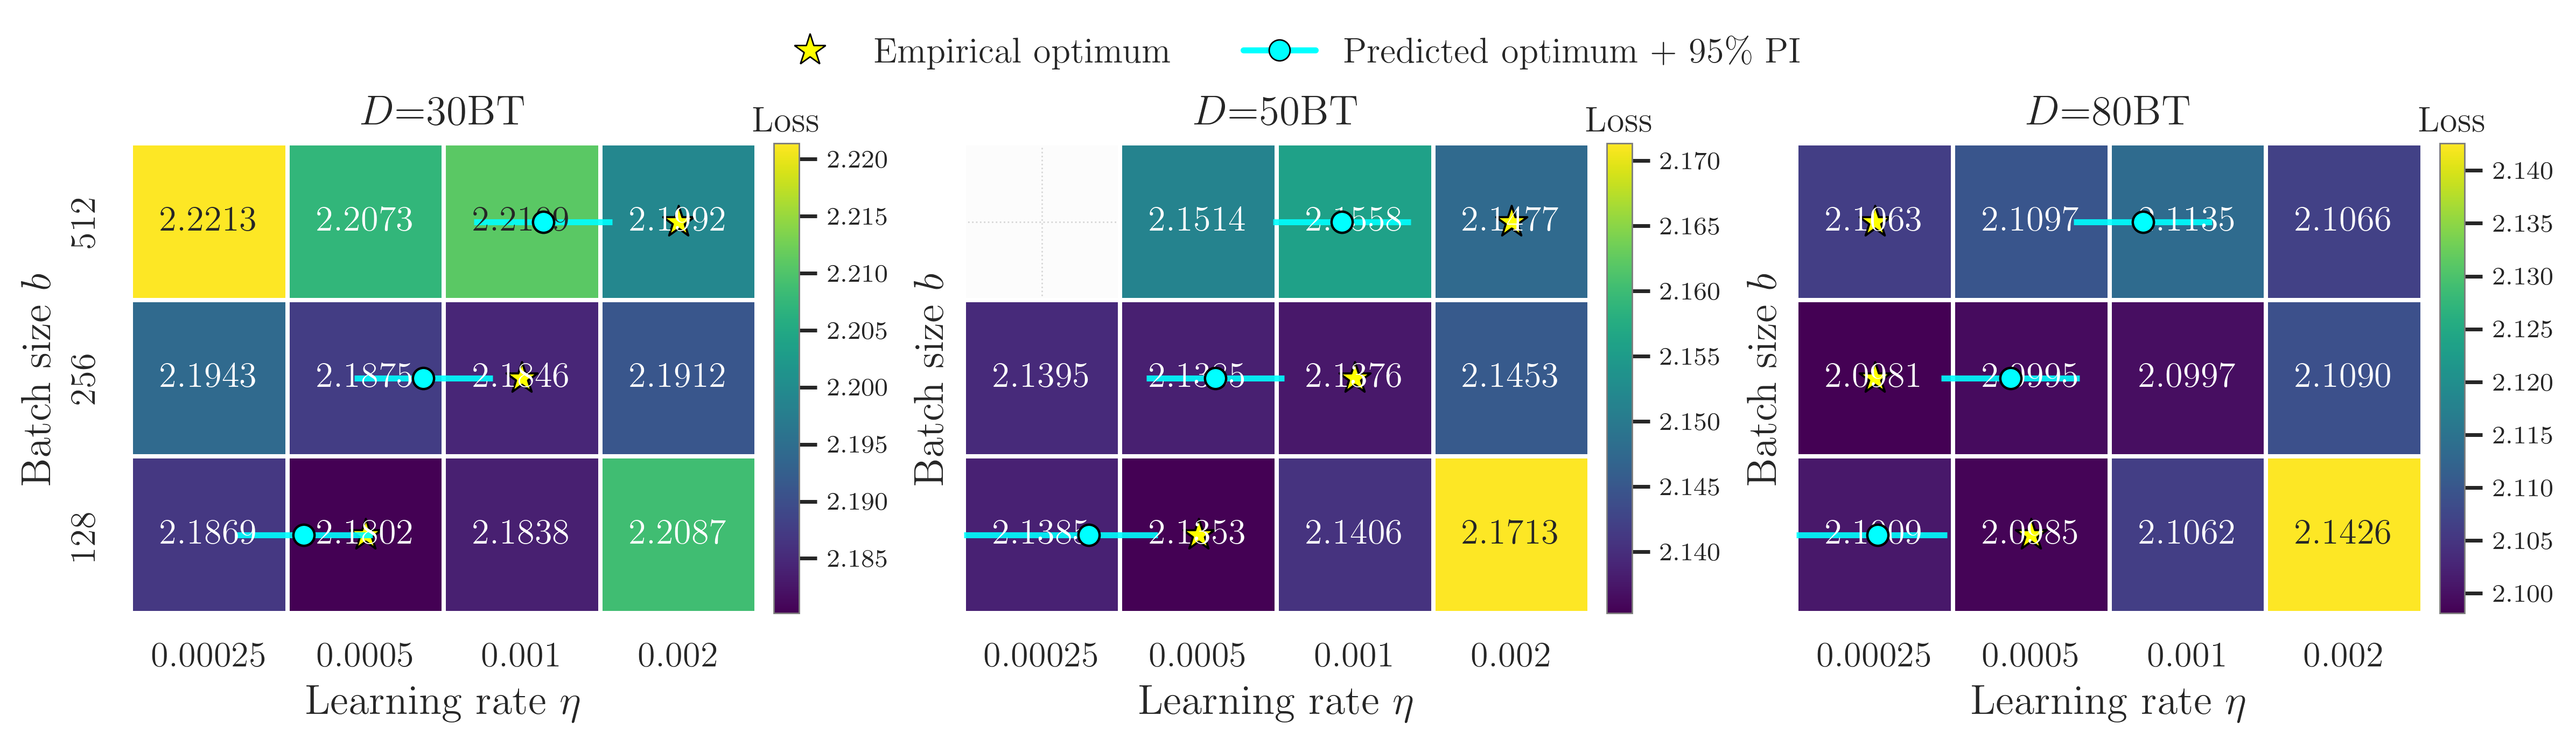

In [17]:
def heatmap_coord(value, values):
    """Map a value to heatmap cell-center coordinates."""
    return np.interp(np.log(value), np.log(values), np.arange(len(values))) + 0.5

def heatmap_boundary(value, values):
    """Map a value to heatmap coordinates, clipping to the heatmap boundaries."""
    if value <= values[0]:
        return 0.0
    if value >= values[-1]:
        return float(len(values))
    return np.interp(np.log(value), np.log(values), np.arange(len(values))) + 0.5


N = N_new
lrs = sorted(df_all[df_all.N == N]["lr"].unique())

fig, axes = plt.subplots(1, len(D_new), figsize=(4 * len(D_new), 4), sharey=True)

if len(D_new) == 1:
    axes = [axes]

for ax, D in zip(axes, D_new):

    gt = df_all[(df_all.N == N) & (df_all.D == D)]

    pivot = gt.pivot_table(index="gbsz", columns="lr", values="loss", aggfunc="min").reindex(index=b_new, columns=lrs)

    hm = sns.heatmap(
        pivot, ax=ax, cmap="viridis", annot=True, 
        annot_kws={"fontsize": ANNOT_FONTSIZE},
        fmt=".4f", cbar=False, square=True, linewidths=1.1, linecolor="white")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)
    cbar = fig.colorbar(hm.collections[0], cax=cax)
    cbar.ax.set_title("Loss", pad=4, fontsize=CBAR_TITLE_FONTSIZE)
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

    for txt in ax.texts:
        txt.set_zorder(20)

    ax.invert_yaxis()
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)

    # ==========================================================
    # empirical optimum + predicted optimum + 95% PI
    # ==========================================================

    for y, bs in enumerate(b_new):

        row = pivot.loc[bs].values

        if np.all(np.isnan(row)):
            continue

        x_emp = np.nanargmin(row)

        ax.scatter(x_emp + 0.5, y + 0.5, marker="*", s=120, color="yellow", edgecolor="black", linewidth=0.7, zorder=10)

        pred = df_pred.query("D == @D and gbsz == @bs").iloc[0]

        # Point prediction
        x = heatmap_coord(pred["lr_pred"], lrs)

        ax.scatter(x, y + 0.5, marker="o", s=50, facecolors="cyan", edgecolors="black", linewidth=0.8, zorder=21)

        # 95% PI — clipped to actual heatmap boundaries
        x_lo = heatmap_boundary(pred["lr_pi_lo"], lrs)
        x_hi = heatmap_boundary(pred["lr_pi_hi"], lrs)

        ax.hlines(y + 0.5, x_lo, x_hi, color="cyan", linewidth=2, alpha=0.9, zorder=19)

    ax.set_title(f"$D$={FORMAT_D(D)}T", fontsize=TITLE_FONTSIZE)
    ax.set_xlabel(r"Learning rate $\eta$", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(r"Batch size $b$", fontsize=LABEL_FONTSIZE)

# ==========================================================
# external legend
# ==========================================================

legend_handles = [
    Line2D([0], [0], marker="*", color="none", markerfacecolor="yellow", markeredgecolor="black", markersize=11, markeredgewidth=0.5, label="Empirical optimum"),
    Line2D([0], [0], marker="o", color="cyan", markerfacecolor="cyan", markeredgecolor="black", markersize=7, markeredgewidth=0.5, linewidth=2, label="Predicted optimum + 95\% PI"),
]

fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.91), ncol=2, frameon=False, fontsize=LEGEND_FONTSIZE)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("../fig/lr_scaling/predictions_1_7B_grid_reduced_model.pdf", dpi=400, bbox_inches="tight", pad_inches=0.02)

plt.show()

### Predict quadratic fit minima
Now the same, but with contour lines of the estimated 2D quadratic.

In [18]:
# Loss observations across lr-bsz values for the 1.7B model
df_1_7B_all = df_all[((df_all.N == N_new) & (df_all.D.isin(D_new)))]
df_1_7B_all = df_1_7B_all.reset_index(drop=True)

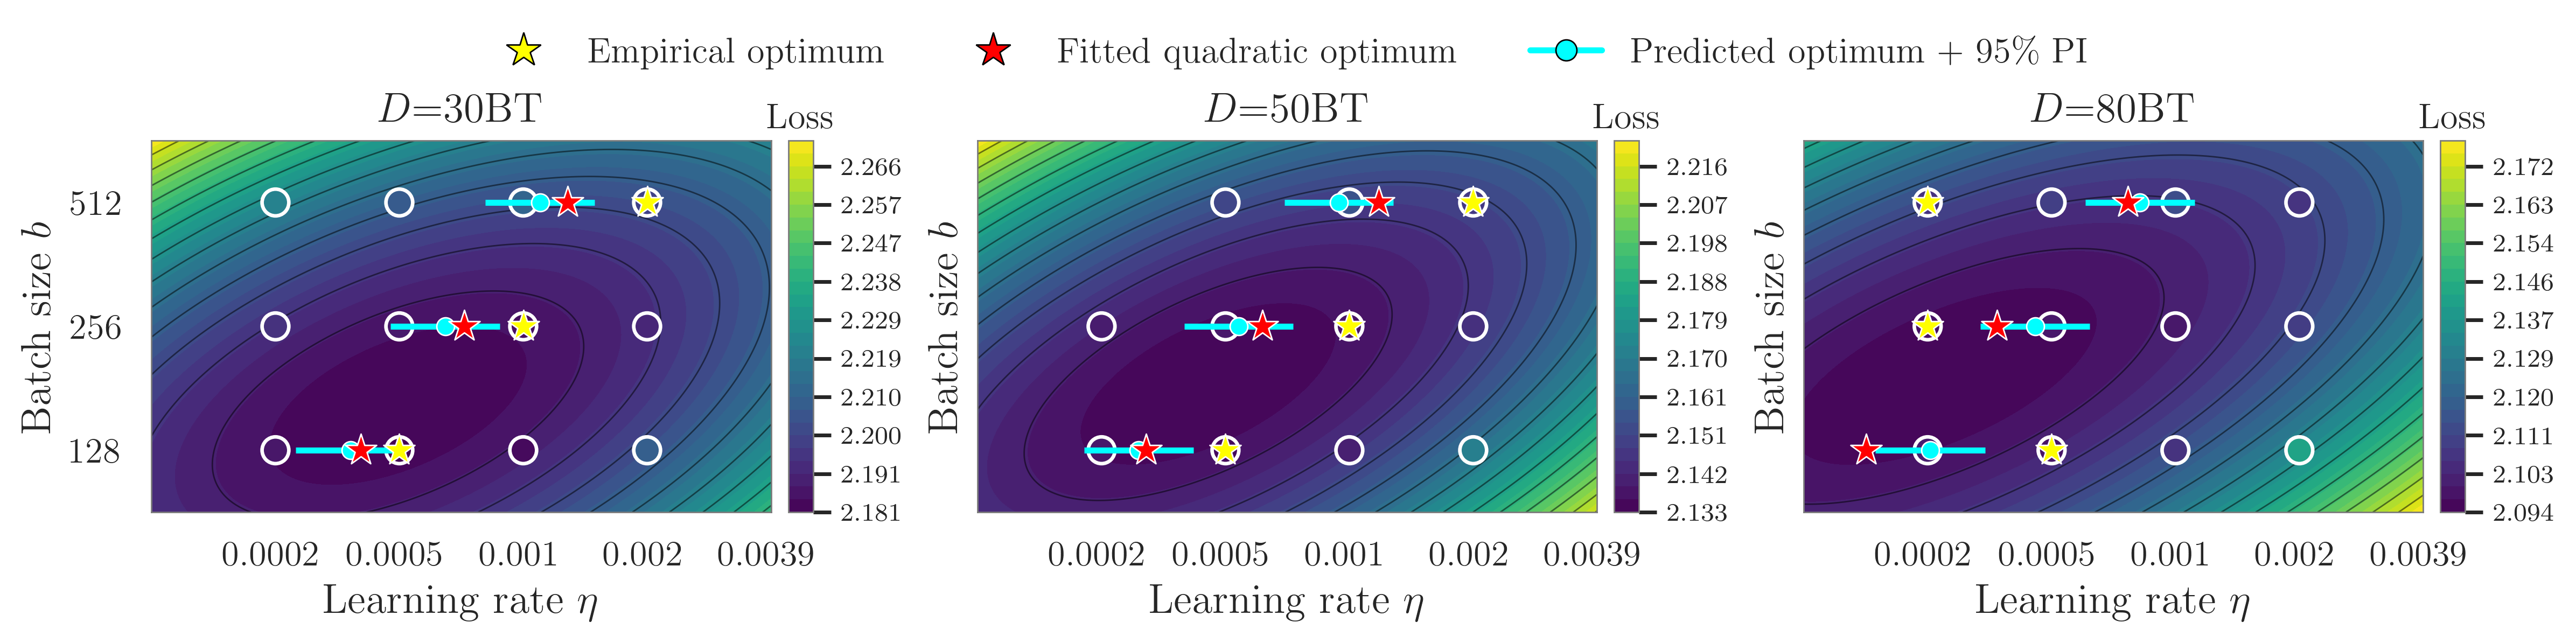

In [19]:
from matplotlib.lines import Line2D

N = N_new

fig, axes = plt.subplots(1, len(D_new), figsize=(4 * len(D_new), 4), sharey=True)

lrs = np.sort(df_1_7B_all.lr.unique())
bszs = np.sort(df_1_7B_all.gbsz.unique())

if len(D_new) == 1:
    axes = [axes]

for ax, D in zip(axes, D_new):

    gt = df_1_7B_all[df_1_7B_all.D == D]

    fit_D = fit_2d_lr_gbsz[(fit_2d_lr_gbsz.N == N) & (fit_2d_lr_gbsz.D == D)].iloc[0]

    # ==========================================================
    # fitted quadratic surface
    # ==========================================================

    x_pad = 1.0
    y_pad = 0.5

    x_vals = np.linspace(np.log2(lrs.min()) - x_pad, np.log2(lrs.max()) + x_pad, 200)
    y_vals = np.linspace(np.log2(bszs.min()) - y_pad, np.log2(bszs.max()) + y_pad, 200)

    X, Y = np.meshgrid(x_vals, y_vals)

    a, b, c, d, e, f_coef = fit_D.coef

    Z = a + b * X + c * X**2 + d * Y + e * Y**2 + f_coef * X * Y

    vmin = Z.min()
    vmax = Z.max()

    norm = Normalize(vmin=vmin, vmax=vmax)

    cf = ax.contourf(X, Y, Z, levels=np.linspace(vmin, vmax, 30), cmap="viridis", norm=norm)
    ax.contour(X, Y, Z, levels=np.linspace(vmin, vmax, 15), colors="black", linewidths=0.5, alpha=0.5)

    # ==========================================================
    # measured grid
    # ==========================================================

    ax.scatter(np.log2(gt.lr), np.log2(gt.gbsz), c=gt.loss, cmap="viridis", vmin=vmin, vmax=vmax, s=80, edgecolors="white", linewidths=1.2, zorder=3)

    # ==========================================================
    # predicted optimum for each observed batch size
    # ==========================================================

    pred_D = df_pred[df_pred.D == D].sort_values("gbsz")

    for _, pred in pred_D.iterrows():

        bs = pred.gbsz

        x = np.log2(pred.lr_pred)
        y = np.log2(bs)

        # Clip CI only to the plotted contour boundaries
        x_lo = max(np.log2(pred.lr_pi_lo), x_vals.min())
        x_hi = min(np.log2(pred.lr_pi_hi), x_vals.max())

        # prediction interval
        ax.hlines(y, x_lo, x_hi, color="cyan", linewidth=2, zorder=20)

        # point prediction
        ax.scatter(x, y, s=35, color="cyan", edgecolors="white", linewidths=0.5, zorder=21)

        # empirical optimum for this batch size
        row = gt[gt.gbsz == bs]

        if len(row):
            emp = row.loc[row.loss.idxmin()]
            ax.scatter(np.log2(emp.lr), np.log2(emp.gbsz), marker="*", s=120, c="yellow", edgecolors="white", linewidths=0.5, zorder=30)

        # fitted optimum for this batch size
        best = df_best_lr_sliced[(df_best_lr_sliced.N == N) & (df_best_lr_sliced.D == D) & (df_best_lr_sliced.gbsz == bs)]

        if not best.empty:
            lr_star = best["lr"].iloc[0]
            ax.scatter(np.log2(lr_star), np.log2(bs), marker="*", s=120, c="red", edgecolors="white", linewidths=0.5, zorder=30)

    # ==========================================================
    # axes
    # ==========================================================

    xticks = np.arange(np.floor(x_vals.min()), np.ceil(x_vals.max()))
    yticks = np.arange(np.floor(y_vals.min()), np.ceil(y_vals.max()))

    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_xticklabels([f"{2**x:.4f}".rstrip("0").rstrip(".") for x in xticks])
    ax.set_yticklabels([f"{2**y:.0f}" for y in yticks])
    ax.set_xlim(x_vals.min(), x_vals.max())
    ax.set_ylim(y_vals.min(), y_vals.max())
    ax.set_aspect("equal")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)
    cbar = fig.colorbar(cf, cax=cax)
    cbar.ax.set_title("Loss", pad=4, fontsize=CBAR_TITLE_FONTSIZE)
    ax.set_xticklabels([f"{2**x:.4f}".rstrip("0").rstrip(".") for x in xticks])

    ax.set_title(f"$D$={FORMAT_D(D)}T", fontsize=TITLE_FONTSIZE)
    ax.set_xlabel(r"Learning rate $\eta$", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(r"Batch size $b$", fontsize=LABEL_FONTSIZE)
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

# ==========================================================
# external legend
# ==========================================================

legend_handles = [
    Line2D([0], [0], marker="*", color="none", markerfacecolor="yellow", markeredgecolor="black", markersize=12, markeredgewidth=0.5, label="Empirical optimum"),
    Line2D([0], [0], marker="*", color="none", markerfacecolor="red", markeredgecolor="black", markersize=12, markeredgewidth=0.5, label="Fitted quadratic optimum"),
    Line2D([0], [0], marker="o", color="cyan", markerfacecolor="cyan", markeredgecolor="black", markersize=7, markeredgewidth=0.5, linewidth=2, label="Predicted optimum + 95\% PI"),
]

fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.85), ncol=3, frameon=False, fontsize=LEGEND_FONTSIZE)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("../fig/lr_scaling/predictions_1_7B_contour_reduced_model.pdf", dpi=400, bbox_inches="tight", pad_inches=0.02)

plt.show()